In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import graph_style as gs
import fig_helper as fh
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter


gs.set_graph_style(1.0)


[[0.518 0.518]
 [0.518 0.518]]
aod.dead_time
aod.freq_to_dist
aod.rise_time
aod.tight.2_ions.imbalances
aod.tight.2_ions.residuals
aod.total_amp
aod.va_vb
aod.wedge_angle
b_field
b_field_nominal
beams.svp_397.adc.channel_idx
beams.svp_397.adc.power_to_adc_fs_offset
beams.svp_397.adc.power_to_adc_fs_slope
beams.svp_397.adc.servo_device
beams.svp_397.servo.ki
beams.svp_397.servo.kp
beams.svp_397.servo.noise_eat_duration
beams.svp_397.servo.noise_eat_interval
beams.svp_397.servo.onset_delay
beams.svp_729.adc.channel_idx
beams.svp_729.adc.power_to_adc_fs_offset
beams.svp_729.adc.power_to_adc_fs_slope
beams.svp_729.adc.servo_device
beams.svp_729.servo.ki
beams.svp_729.servo.kp
beams.svp_729.servo.noise_eat_duration
beams.svp_729.servo.noise_eat_interval
beams.svp_729.servo.onset_delay
beams.svp_854.adc.channel_idx
beams.svp_854.adc.power_to_adc_fs_offset
beams.svp_854.adc.power_to_adc_fs_slope
beams.svp_854.adc.servo_device
beams.svp_854.servo.ki
beams.svp_854.servo.kp
beams.svp_854.servo.n

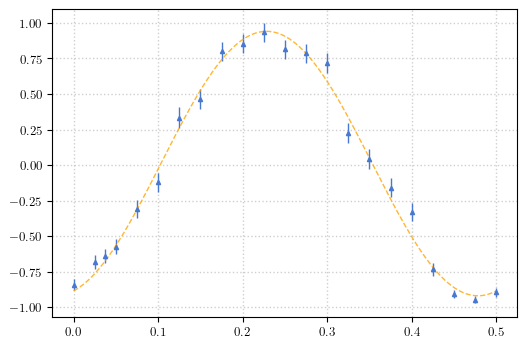

In [34]:
def load_ms_data(rid, date):
    f = fh.load_data(rid, date)
    print(f["archive"]["aod.tight.2_ions.imbalances"])
    for x in f["archive"].keys():
        print(x)


    p00 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_00"])
    p0110 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_01_10"])
    p11 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_11"])
    p_err_00 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_err_00"])
    p_err_0110 = np.array(
        f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_err_01_10"]
    )
    p_err_11 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_err_11"])

    x = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_0"])

    # get args for x>0
    phase_args = np.where(x > 0)
    phase = x[phase_args]
    par_p00 = p00[phase_args]
    par_p0110 = p0110[phase_args]
    par_p11 = p11[phase_args]
    par_err_p00 = p_err_00[phase_args]
    par_err_p0110 = p_err_0110[phase_args]
    par_err_p11 = p_err_11[phase_args]
    parity = par_p00 + par_p11 - par_p0110
    parity_err = np.sqrt(par_err_p00**2 + par_err_p11**2 + par_err_p0110**2)


    pop_args = np.where(x < 0)
    pop_reps = x[pop_args]
    pop_p00 = p00[pop_args]
    pop_p0110 = p0110[pop_args]
    pop_p11 = p11[pop_args]
    pop_err_p00 = p_err_00[pop_args]
    pop_err_p0110 = p_err_0110[pop_args]
    pop_err_p11 = p_err_11[pop_args]

    pop_F = pop_p0110
    pop_err_F = pop_err_p0110

    return phase, parity, parity_err, pop_reps, pop_F, pop_err_F

def pop_arr_F(p0110_arr, p_err_0110_arr):
    pop_err = np.mean(p0110_arr)
    pop_err_std = np.std(p0110_arr) / np.sqrt(len(p0110_arr))
    return pop_err, pop_err_std

def sinusoid_func(x, a, b, c, d):
    return a * np.sin(b * x + c) + d


date = "2026-06-07"
rid = 129415

phase, parity, parity_err, duration, p0110, p_err_0110 = load_ms_data(rid, date)

pop_err, pop_err_std = pop_arr_F(p0110, p_err_0110)

d=0.000001
p_fit, p_cov = curve_fit(
    sinusoid_func,
    phase,
    parity,
    p0=[1, 4*np.pi, 0, 0],
    sigma=parity_err,
    bounds=([-1, 4*np.pi-d, -np.pi, -1], [1, 4*np.pi+d, np.pi, 1]),
    absolute_sigma=True,
)
x_fit = np.linspace(np.min(phase), np.max(phase), 1000)
y_fit = sinusoid_func(x_fit, *p_fit)

fit_err = np.sqrt(np.diag(p_cov))
contrast = np.abs(p_fit[0])
contrast_err = fit_err[0]

fidelity = (contrast + 1-pop_err) / 2
fidelity_err = np.sqrt((contrast_err / 2) ** 2 + (pop_err_std / 2) ** 2)

print(f"Pop error: {pop_err:.3f} ± {pop_err_std:.3f}")
print(f"Contrast: {contrast:.3f} ± {contrast_err:.3f}")
print(f"Fidelity: {fidelity:.3f} ± {fidelity_err:.3f}")

# Fidelity due to 1/2 a pulse?
# Assume depolarisation errors, so the fidelity of a 1/2 pulse is sqrt(F), and the error is 1/2 * F_err / sqrt(F)
pi4_fidelity = np.sqrt(fidelity)
pi4_fidelity_err = 0.5 * fidelity_err / np.sqrt(fidelity)
print(f"Pi/4 Fidelity: {pi4_fidelity:.5f} ± {pi4_fidelity_err:.5f}")
# Assume independent stochastic errors
pi4_fidelity = 1- (1-fidelity)/2
pi4_fidelity_err = 0.5 * fidelity_err
print(f"Pi/4 Fidelity: {pi4_fidelity:.5f} ± {pi4_fidelity_err:.5f}")


fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    phase,
    parity,
    yerr=parity_err,
    fmt="^")
ax.plot(
    x_fit,
    y_fit,
    color="orange",
    alpha=0.8,
    label="Parity fit")
